In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.optim as optim
 


In [17]:
# -----------------------
# 1. Generate diffusion data (Dirichlet BC)
# -----------------------
def diffusion_solver_dirichlet(u0, nu=0.01, dx=1/128, dt=1e-4, n_steps=2000):
    """Explicit finite-difference solver for 1D diffusion (Dirichlet BCs u(0,t)=u(1,t)=0)."""
    u = u0.copy()
    Nx = len(u)
    traj = [u.copy()]
    for _ in range(n_steps):
        un = u.copy()

        # discrete Laplacian on interior points only (no np.roll)
        lap = (un[2:] - 2*un[1:-1] + un[:-2]) / dx**2
        u[1:-1] = un[1:-1] + nu * dt * lap

        # Dirichlet boundaries
        u[0] = 0.0
        u[-1] = 0.0

        traj.append(u.copy())
    return np.stack(traj)  # shape (T, Nx)

def generate_diffusion_data(Nx=128, nu=0.01, dt=1e-4, n_steps=4000):
    dx = 1.0 / (Nx - 1)
    x = np.linspace(0, 1, Nx)

    # initial condition compatible with Dirichlet BC
    u0 = np.sin(2*np.pi * x)   # = 0 at x=0 and x=1

    data = diffusion_solver_dirichlet(u0, nu, dx, dt, n_steps)
    return x, data  # data[t, x]

# -----------------------
# 3. Training setup
# -----------------------
Nx =500
dt0 = 1e-4
nu = 0.01
Nt = 20000

x, data = generate_diffusion_data(Nx, nu, dt0, Nt)


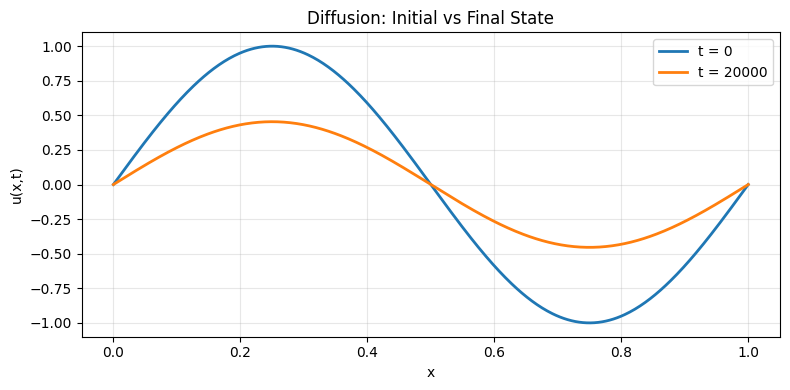

In [ ]:
t_plot = n_steps  # or whatever final index you used

plt.figure(figsize=(8,4))
plt.plot(x, data[0], label="t = 0", linewidth=2)
plt.plot(x, data[t_plot], label=f"t = {t_plot}", linewidth=2)
plt.title("Diffusion: Initial vs Final State")
plt.xlabel("x")
plt.ylabel("u(x,t)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# -----------------------
# Linear predictor: library + basis (min_θ ||U_act - X@Θ||^2 + λ||Θ||^2)
# -----------------------
# Library: basis exponents j, k (formula: Σ U_NN Δt^j Δx^k Θ_jk)
J_LIST = list(range(-2, 3))   # j in {-2,-1,0,1,2}
K_LIST = list(range(-2, 3))   # k in {-2,-1,0,1,2}
dx_phys = 1.0 / (Nx - 1)
dt_phys = dt0

def nearest5_for_point(t_pt, x_pt, Nt, Nx, dt_phys, dx_phys):
    """Return 5 nearest grid points (by physical distance) to (t_pt, x_pt), excluding the point itself."""
    cand = []
    for t in range(Nt + 1):
        for x in range(Nx):
            if t == t_pt and x == x_pt:
                continue
            d = np.sqrt((dt_phys * (t - t_pt))**2 + (dx_phys * (x - x_pt))**2)
            cand.append((d, t, x))
    cand.sort(key=lambda e: e[0])
    return [(t, x) for (_, t, x) in cand[:5]]

def build_feature_row(data, t_pt, x_pt, neigh5, J_LIST, K_LIST, dt_phys, dx_phys):
    """One row of X: for each (j,k), feature = Σ_n U_NN(n) * Δt_n^j * Δx_n^k."""
    row = []
    for j in J_LIST:
        for k in K_LIST:
            val = 0.0
            for (tn, xn) in neigh5:
                dt_n = dt_phys * (t_pt - tn)
                dx_n = dx_phys * (x_pt - xn)
                u_nn = data[tn, xn]
                val += u_nn * (dt_n ** j) * (dx_n ** k)
            row.append(val)
    return np.array(row, dtype=np.float64)

def build_X_y(data, n_samples, Nt, Nx, dt_phys, dx_phys, J_LIST, K_LIST, rng=np.random):
    """Sample interior points; build design matrix X and target vector y = U_act."""
    n_basis = len(J_LIST) * len(K_LIST)
    X = np.zeros((n_samples, n_basis))
    y = np.zeros(n_samples)
    for i in range(n_samples):
        t_pt = rng.randint(1, Nt)      # interior in t
        x_pt = rng.randint(1, Nx - 1)  # interior in x (avoid BC)
        neigh5 = nearest5_for_point(t_pt, x_pt, Nt, Nx, dt_phys, dx_phys)
        X[i] = build_feature_row(data, t_pt, x_pt, neigh5, J_LIST, K_LIST, dt_phys, dx_phys)
        y[i] = data[t_pt, x_pt]
    return X, y

# Build training data (use same Nt,Nx as data shape: data has shape (Nt+1, Nx))
_nt, _nx = data.shape[0] - 1, data.shape[1]
n_samples = 2000
X_train, y_train = build_X_y(data, n_samples, _nt, _nx, dt_phys, dx_phys, J_LIST, K_LIST)
print("Library: j in", J_LIST, ", k in", K_LIST, "→", X_train.shape[1], "basis functions")
print("X_train shape:", X_train.shape, ", y_train shape:", y_train.shape)

In [19]:
import numpy as np
import random
 
def candidates_within_radius(visited, R):
    Nt, Nx = visited.shape
    visited_pts = np.argwhere(visited)  # (K,2)

    cand = set()
    for (t0, x0) in visited_pts:
        t_min, t_max = max(0, t0-R), min(Nt-1, t0+R)
        x_min, x_max = max(0, x0-R), min(Nx-1, x0+R)
        for t in range(t_min, t_max+1):
            for x in range(x_min, x_max+1):
                if not visited[t,x]:
                    if (t - t0)**2 + (x - x0)**2 <= R*R:
                        cand.add((t,x))
    return list(cand)


def nearest5(visited, t_new, x_new):
    pts = np.argwhere(visited)
    dt = pts[:,0] - t_new
    dx = pts[:,1] - x_new
    d = np.sqrt(dt*dt + dx*dx)
    idx = np.argsort(d)[:5]
    return [(int(pts[i,0]), int(pts[i,1])) for i in idx]


def generate_next_point(visited, R=5):
    cand = candidates_within_radius(visited, R)
    if len(cand) == 0:
        return None, None
    t_new, x_new = random.choice(cand)
    neigh = nearest5(visited, t_new, x_new)
    return (t_new, x_new), neigh


In [20]:
import numpy as np
import random
import matplotlib.pyplot as plt

def candidates_within_radius(visited, R):
    Nt, Nx = visited.shape
    visited_pts = np.argwhere(visited)  # (K,2)

    cand = set()
    for (t0, x0) in visited_pts:
        t_min, t_max = max(0, t0-R), min(Nt-1, t0+R)
        x_min, x_max = max(0, x0-R), min(Nx-1, x0+R)
        for t in range(t_min, t_max+1):
            for x in range(x_min, x_max+1):
                if not visited[t,x]:
                    if (t - t0)**2 + (x - x0)**2 <= R*R:
                        cand.add((t,x))
    return list(cand)


def nearest5(visited, t_new, x_new):
    pts = np.argwhere(visited)
    dt = pts[:,0] - t_new
    dx = pts[:,1] - x_new
    d = np.sqrt(dt*dt + dx*dx)
    idx = np.argsort(d)[:5]
    return [(int(pts[i,0]), int(pts[i,1])) for i in idx]


def generate_next_point(visited, R=5):
    cand = candidates_within_radius(visited, R)
    if len(cand) == 0:
        return None, None
    t_new, x_new = random.choice(cand)
    neigh = nearest5(visited, t_new, x_new)
    return (t_new, x_new), neigh


def visualize_step(visited, new_pt, neigh5):
    pts = np.argwhere(visited)
    ts = pts[:,0]
    xs = pts[:,1]

    plt.figure(figsize=(5,5))
    # visited points (IC + BC for now)
    plt.scatter(xs, ts, c='lightgray', s=50, label='visited (IC/BC)')

    # new point
    t_new, x_new = new_pt
    plt.scatter([x_new], [t_new], c='red', s=120, label='new point')

    # neighbors
    neigh_ts = [t for (t,x) in neigh5]
    neigh_xs = [x for (t,x) in neigh5]
    plt.scatter(neigh_xs, neigh_ts, c='blue', s=80, label='nearest 5')

    # edges
    for (t_n, x_n) in neigh5:
        plt.plot([x_new, x_n], [t_new, t_n], 'k--', alpha=0.8)

    plt.xlabel('x')
    plt.ylabel('t')
    plt.title('New Point and Its 5 Nearest Visited Points')
    plt.legend()
    plt.tight_layout()
    plt.show()


In [24]:

visited = np.zeros((Nt, Nx), bool)

# IC (t=0 at bottom)
visited[0, :] = True

# BCs (left and right)
visited[:, 0] = True
visited[:, Nx-1] = True

(new_pt, neigh5) = generate_next_point(visited, R=5)
visualize_step(visited, new_pt, neigh5)


TypeError: nearest5() missing 1 required positional argument: 'Rx'

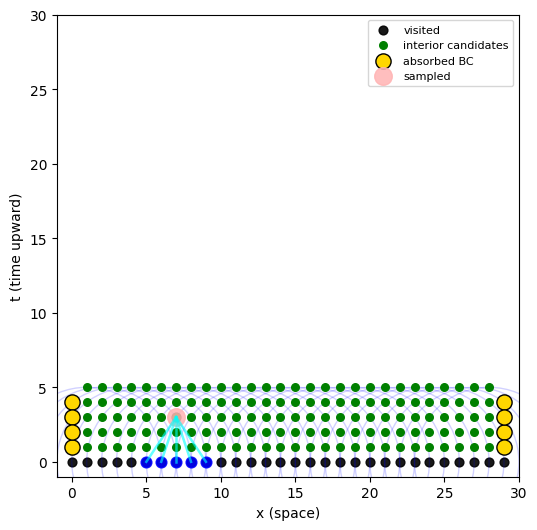

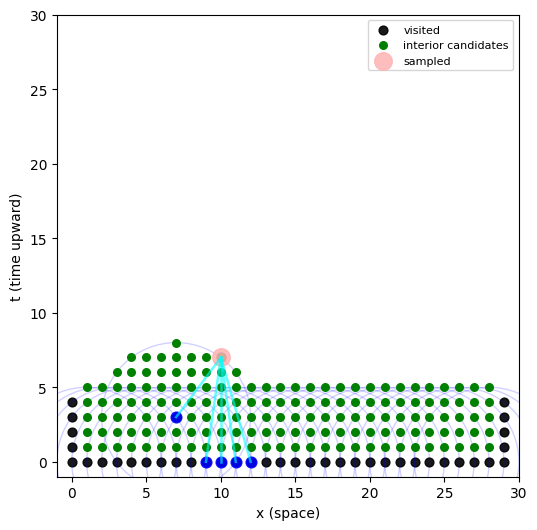

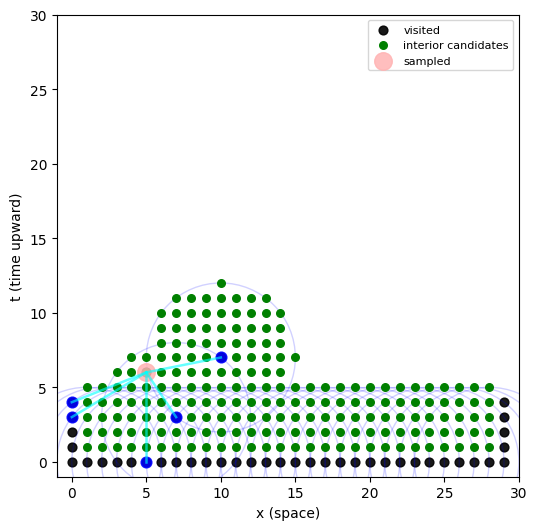

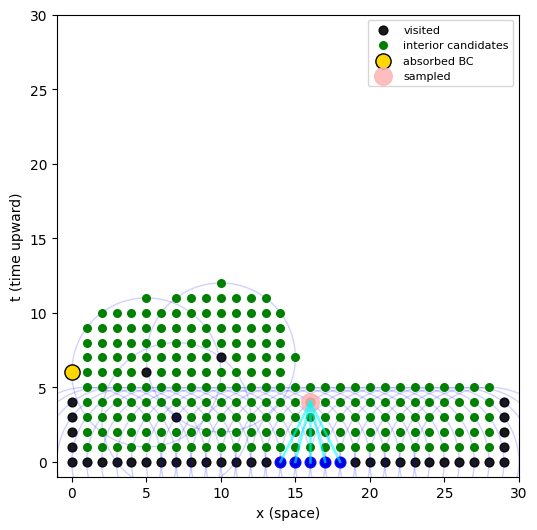

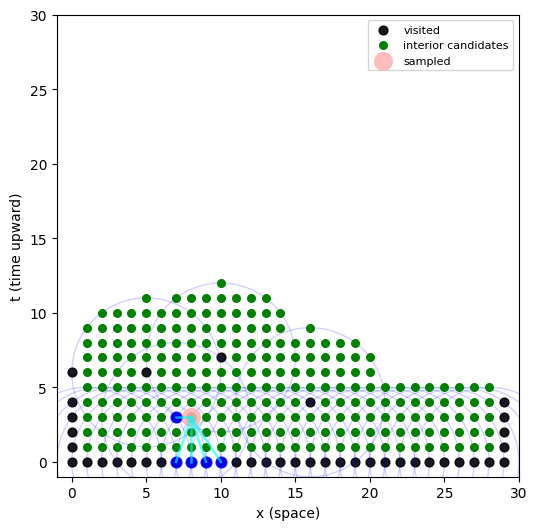

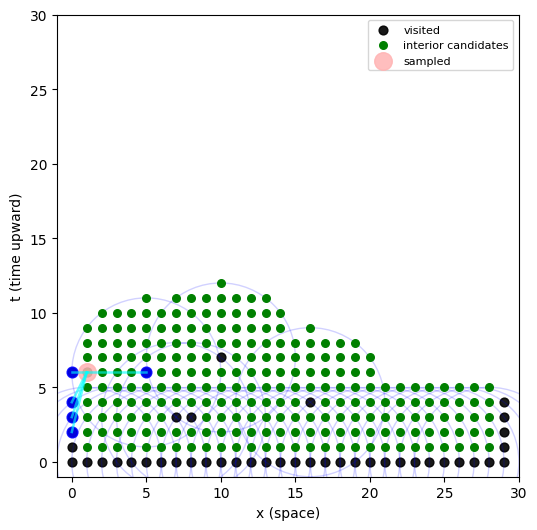

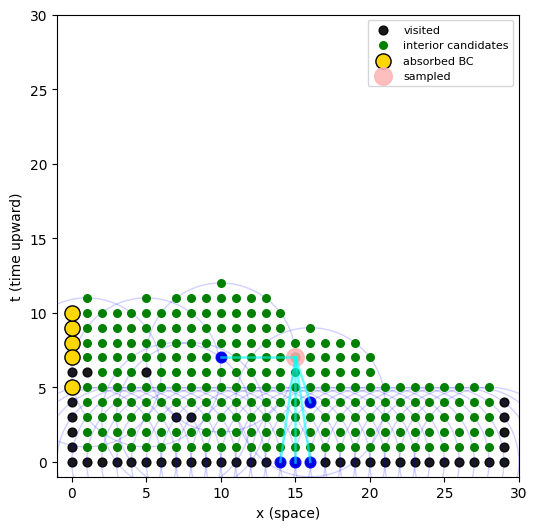

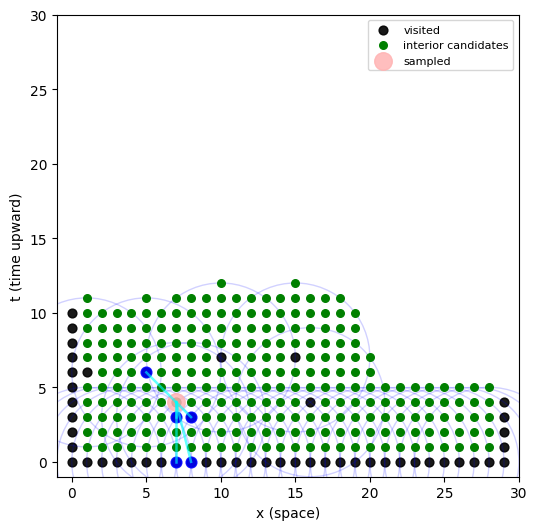

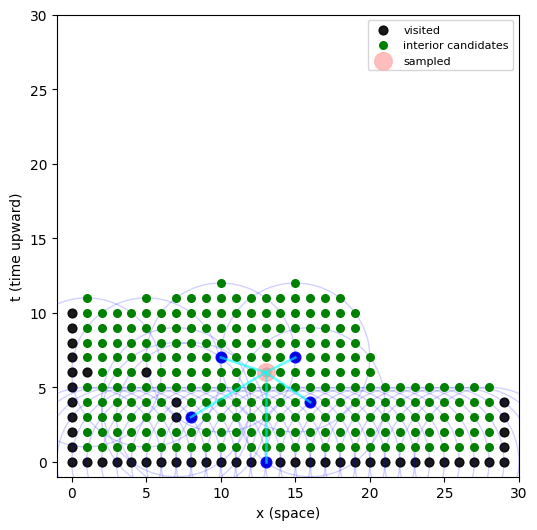

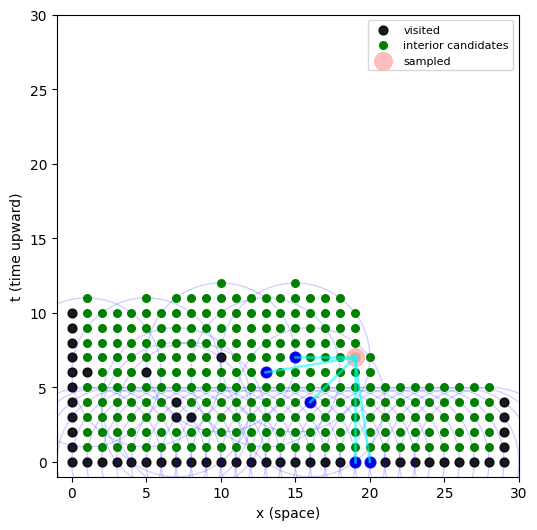

In [27]:
# %% Growth + passive BC + nearest-5 visualization

import numpy as np
import random
import matplotlib.pyplot as plt

def build_bc_mask(Nt, Nx):
    """BC = left/right boundaries."""
    is_bc = np.zeros((Nt, Nx), dtype=bool)
    is_bc[:, 0] = True
    is_bc[:, Nx-1] = True
    return is_bc


def candidates_from_interior(visited, is_bc, R):
    """
    Generate candidate points from radius circles around
    visited interior (non-BC) points ONLY.
    """
    Nt, Nx = visited.shape
    interior_centers = np.argwhere(visited & (~is_bc))
    cand = set()

    for (t0, x0) in interior_centers:
        t_min, t_max = max(0, t0-R), min(Nt-1, t0+R)
        x_min, x_max = max(0, x0-R), min(Nx-1, x0+R)
        for t in range(t_min, t_max+1):
            for x in range(x_min, x_max+1):
                if not visited[t, x] and (t-t0)**2 + (x-x0)**2 <= R*R:
                    cand.add((t, x))

    return list(cand), interior_centers


def nearest5(visited_pts, sampled):
    """Pick 5 nearest points (excluding sampled)."""
    if len(visited_pts) == 0:
        return np.zeros((0, 2), dtype=int)

    dt = visited_pts[:, 0] - sampled[0]
    dx = visited_pts[:, 1] - sampled[1]
    d = dt*dt + dx*dx          # squared distance is sufficient
    idx = np.argsort(d)[:5]
    return visited_pts[idx]


def step_visual(visited, is_bc, R=5):
    Nt, Nx = visited.shape

    # ---- candidate generation from interior only ----
    cand, interior_centers = candidates_from_interior(visited, is_bc, R)

    if len(cand) == 0:
        print("No more candidates")
        return visited

    # ---- absorb BC passively (BC becomes visited but passive) ----
    absorbed_bc = []
    for (t, x) in cand:
        if is_bc[t, x]:
            visited[t, x] = True
            absorbed_bc.append((t, x))

    # ---- interior candidates for sampling ----
    interior_cand = [(t, x) for (t, x) in cand
                     if (not is_bc[t, x]) and (not visited[t, x])]

    # ---- sample interior point (but compute nearest before marking visited) ----
    sampled = None
    neigh = None
    if interior_cand:
        sampled = random.choice(interior_cand)

        # nearest-5 BEFORE marking sampled as visited
        visited_pts = np.argwhere(visited)
        neigh = nearest5(visited_pts, sampled)

        # now commit sampled point as visited
        visited[sampled[0], sampled[1]] = True

    # ---- visualization ----
    fig, ax = plt.subplots(figsize=(6, 6))

    # plot all visited (interior + BC same)
    vpts = np.argwhere(visited)
    ax.scatter(vpts[:,1], vpts[:,0], s=40, c='black', alpha=0.9, label='visited')

    # circles from interior only
    for (t0, x0) in interior_centers:
        circle = plt.Circle((x0, t0), R, fill=False, color='blue', alpha=0.18)
        ax.add_patch(circle)

    # interior candidates
    if interior_cand:
        cx = [x for (t, x) in interior_cand]
        ct = [t for (t, x) in interior_cand]
        ax.scatter(cx, ct, c='green', s=30, label='interior candidates')

    # newly absorbed BC
    if absorbed_bc:
        ax.scatter([x for (_, x) in absorbed_bc],
                   [t for (t, _) in absorbed_bc],
                   c='gold', edgecolors='k', s=120, label='absorbed BC')

    # sampled + nearest-5 stencil
    if sampled is not None:
        ts, xs = sampled
        # pale red sampled point
        ax.scatter(xs, ts, c='#ffb3b3', s=160, alpha=0.85, label='sampled')

        # stencil arrows
        for (tn, xn) in neigh:
            ax.plot([xs, xn], [ts, tn], color='cyan', alpha=0.60, linewidth=1.8)
            ax.scatter([xn], [tn], c='blue', s=60, alpha=0.85)

    ax.set_xlim(-1, Nx)
    ax.set_ylim(-1, Nt)
    ax.set_xlabel("x (space)")
    ax.set_ylabel("t (time upward)")
    ax.set_aspect('equal', 'box')
    ax.legend(fontsize=8)
    plt.show()

    return visited


# ---- Initialization ----
Nt, Nx = 30, 30
visited = np.zeros((Nt, Nx), dtype=bool)
visited[0, :] = True      # IC only

is_bc = build_bc_mask(Nt, Nx)

# ---- Run growth ----
for _ in range(10):
    visited = step_visual(visited, is_bc, R=5)


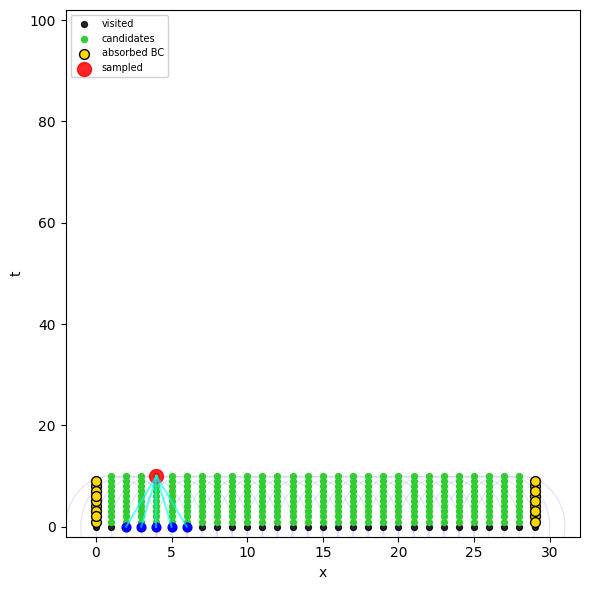

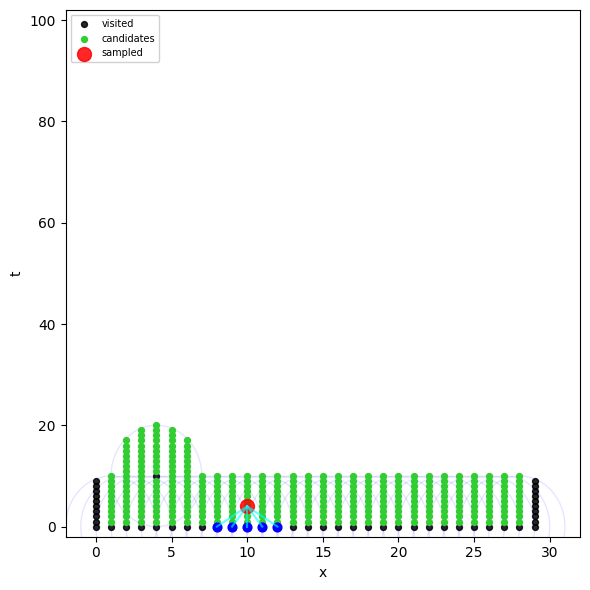

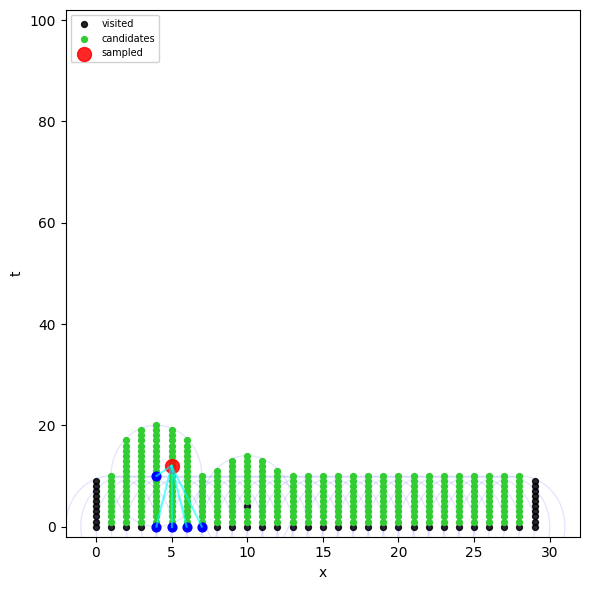

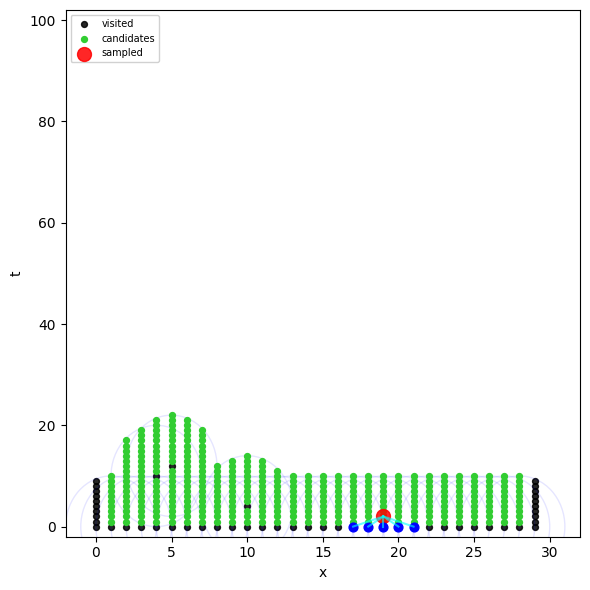

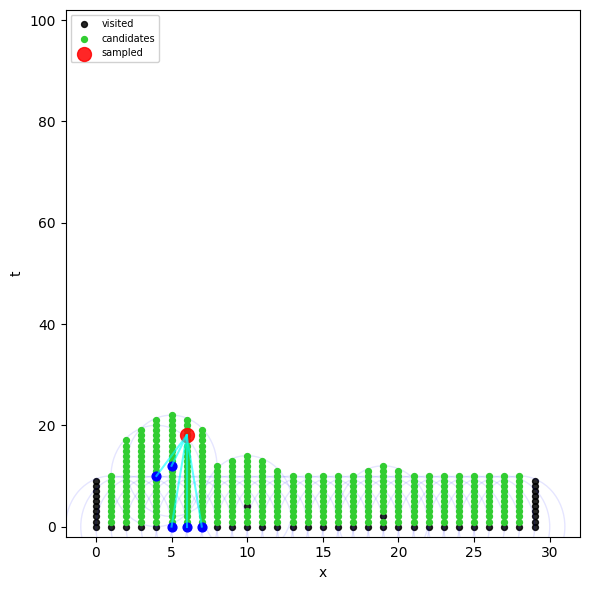

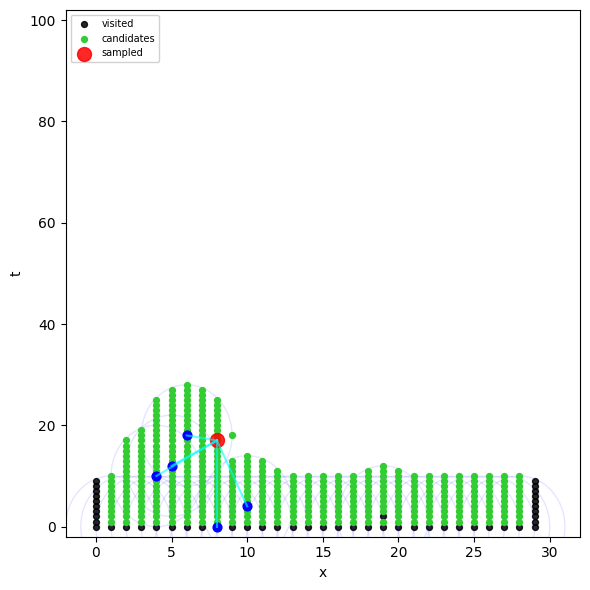

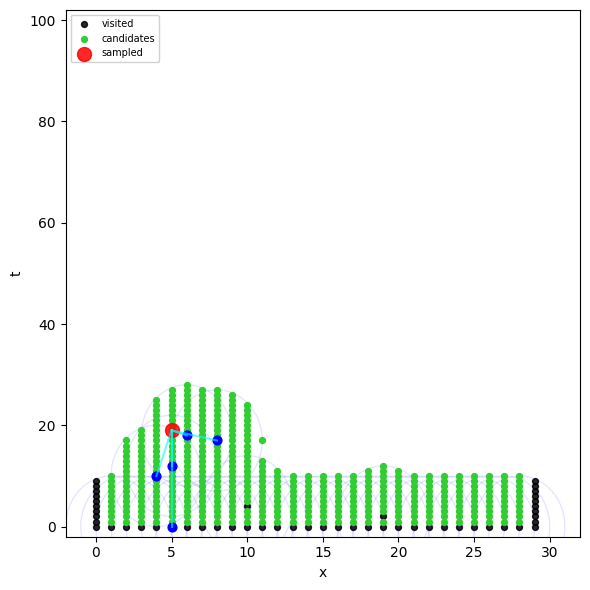

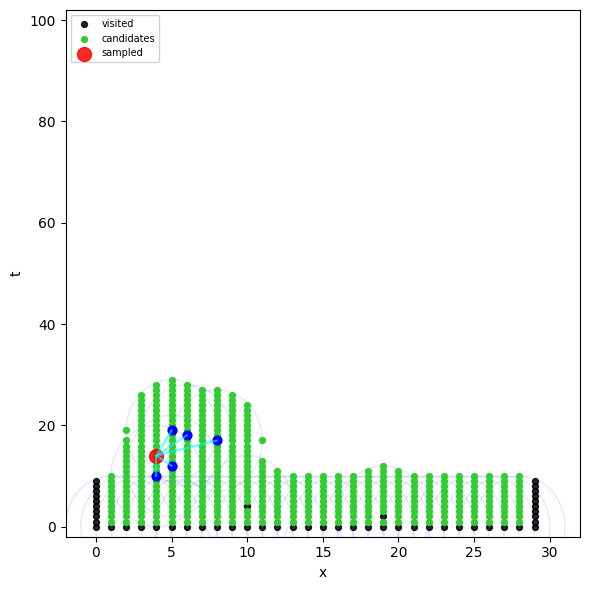

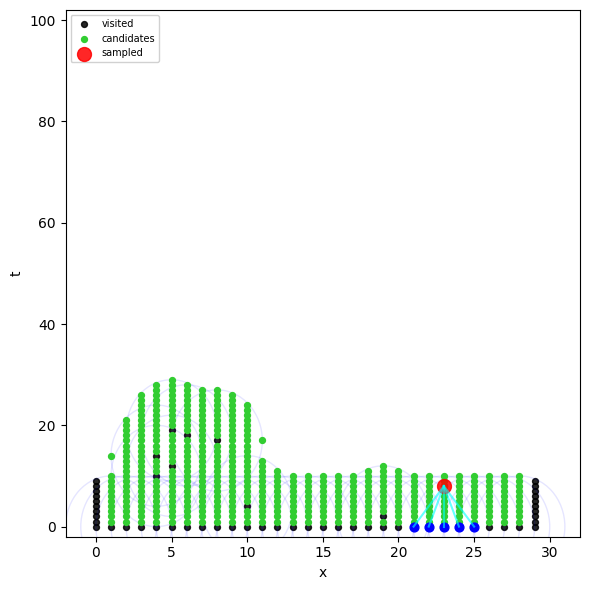

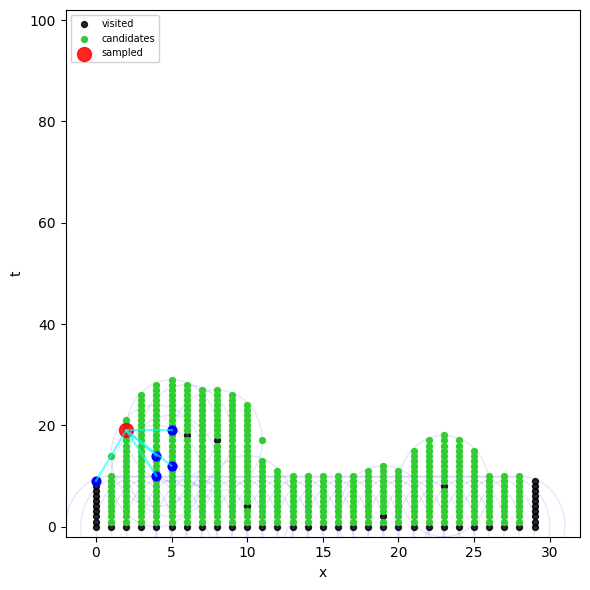

In [ ]:
# %% Growth + passive BC + nearest-5 visualization (elliptical version)

import numpy as np
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches


def build_bc_mask(Nt, Nx):
    """BC = left/right boundaries."""
    is_bc = np.zeros((Nt, Nx), dtype=bool)
    is_bc[:, 0] = True
    is_bc[:, Nx-1] = True
    return is_bc


def candidates_from_interior(visited, is_bc, R, Rt, Rx):
    """
    Generate candidate points from elliptical neighborhoods
    around visited interior (non-BC) points ONLY.
    
    Ellipse condition:
        ((t-t0)/Rt)^2 + ((x-x0)/Rx)^2 <= 1
    """
    Nt, Nx = visited.shape
    interior_centers = np.argwhere(visited & (~is_bc))
    cand = set()

    for (t0, x0) in interior_centers:
        
        # integer bounding box for the ellipse
        t_min = max(0, int(t0 - Rt))
        t_max = min(Nt-1, int(t0 + Rt))
        x_min = max(0, int(x0 - Rx))
        x_max = min(Nx-1, int(x0 + Rx))

        for t in range(t_min, t_max+1):
            for x in range(x_min, x_max+1):
                
                dt = (t - t0) / Rt
                dx = (x - x0) / Rx

                # ellipse inclusion test
                if not visited[t, x] and dt*dt + dx*dx <= 1.0:
                    cand.add((t, x))

    return list(cand), interior_centers


def nearest5(visited_pts, sampled, Rt, Rx):
    """
    Select nearest-5 visited points using elliptical metric.
    """
    dt = (visited_pts[:, 0] - sampled[0]) / Rt
    dx = (visited_pts[:, 1] - sampled[1]) / Rx
    d = dt*dt + dx*dx
    idx = np.argsort(d)[:5]
    return visited_pts[idx]

def step_visual(visited, is_bc, R=5):
    Nt, Nx = visited.shape

    # ellipse radii (data coordinates)
    Rt = R
    Rx = R * (Nx / Nt)

    # generate candidates
    cand, interior_centers = candidates_from_interior(visited, is_bc, R, Rt, Rx)

    if len(cand) == 0:
        print("No more candidates")
        return visited

    # absorb BC
    absorbed_bc = []
    for (t, x) in cand:
        if is_bc[t, x]:
            visited[t, x] = True
            absorbed_bc.append((t, x))

    # interior candidates
    interior_cand = [(t, x) for (t, x) in cand
                     if (not is_bc[t, x]) and (not visited[t, x])]

    # sample interior
    sampled = None
    neigh = None
    if interior_cand:
        sampled = random.choice(interior_cand)
        visited_pts = np.argwhere(visited)
        neigh = nearest5(visited_pts, sampled, Rt, Rx)
        visited[sampled[0], sampled[1]] = True

    # ---- visualization ----

    fig, ax = plt.subplots(figsize=(6, 6))   # square visual output

    # visited points
    vpts = np.argwhere(visited)
    ax.scatter(vpts[:,1], vpts[:,0], s=18, c='black', alpha=0.85, label='visited')

    # draw ellipses around interior centers
    for (t0, x0) in interior_centers:
        ellipse = patches.Ellipse((x0, t0), width=2*Rx, height=2*Rt,
                                  fill=False, color='blue', alpha=0.10, linewidth=1.0)
        ax.add_patch(ellipse)

    if interior_cand:
        cx = [x for (t, x) in interior_cand]
        ct = [t for (t, x) in interior_cand]
        ax.scatter(cx, ct, c='limegreen', s=18, label='candidates')

    if absorbed_bc:
        bx = [x for (_, x) in absorbed_bc]
        bt = [t for (t, _) in absorbed_bc]
        ax.scatter(bx, bt, c='gold', edgecolors='black', s=50, label='absorbed BC')

    if sampled is not None:
        ts, xs = sampled
        ax.scatter(xs, ts, c='red', s=100, alpha=0.85, label='sampled')
        for (tn, xn) in neigh:
            ax.plot([xs, xn], [ts, tn], color='cyan', alpha=0.6, linewidth=1.5)
            ax.scatter([xn], [tn], c='blue', s=40)

    ax.set_xlim(-2, Nx+2)
    ax.set_ylim(-2, Nt+2)
    ax.set_xlabel("x")
    ax.set_ylabel("t")

    # key fix: do NOT force data geometry as visual aspect
    ax.set_aspect('auto')

    ax.legend(loc='upper left', fontsize=7, framealpha=0.9)
    plt.tight_layout()
    plt.show()

    return visited


# ---- Example Run ----
Nt, Nx = 100, 30   # non-square aspect to show ellipse scaling
visited = np.zeros((Nt, Nx), bool)
visited[0, :] = True
is_bc = build_bc_mask(Nt, Nx)
for _ in range(10):

    visited = step_visual(visited, is_bc, R=10)